In [1]:
import pandas as pd
from xgboost import XGBClassifier
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, RocCurveDisplay
import sys
import matplotlib.pyplot as plt

# Point to project root
project_root = str(Path.cwd().parent.parent)
if project_root not in sys.path:
    sys.path.append(project_root)

from src.utils.paths import PROCESSED_DATA_DIR

In [2]:
# 1. Load the preprocessed data
X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")
y_train = pd.read_csv(PROCESSED_DATA_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").squeeze()

# 2. Initialize the model
clf = XGBClassifier(random_state=42)

# 3. Train the model
clf.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

# 5. Evaluate the results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test,y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.965815041381792
ROC AUC Score: 0.9594412713489262

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      4115
           1       0.94      0.93      0.93      1443

    accuracy                           0.97      5558
   macro avg       0.96      0.95      0.96      5558
weighted avg       0.97      0.97      0.97      5558



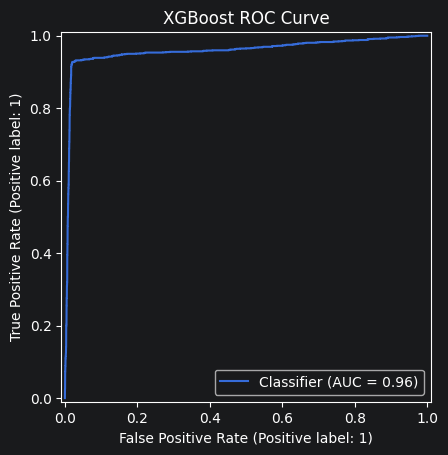

In [3]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("XGBoost ROC Curve")
plt.show()